# Alexa Voice Assistant

## 1. Importing Libraries and Installing Dependencies

This section imports all the required libraries for the voice assistant, including audio recording, speech recognition, text processing, machine learning, and text-to-speech functionality. It also displays the active Python environment (sys.prefix) and installs all necessary dependencies using pip to ensure the application runs correctly.

In [98]:
import sys
import sounddevice as sd
from scipy.io.wavfile import write
import os
import subprocess
import urllib
import whisper
import soundfile as sf
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import webbrowser
import datetime
import random
import re
import pyttsx3
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [2]:
print(sys.prefix)

C:\Users\sarat\anaconda3\envs\deep_learning


In [46]:
!pip install pyautogui sounddevice scipy openai-whisper pyttsx3 torch scikit-learn pandas numpy==2.3.0 seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.3 MB 13.7 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 14.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 14.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.2 MB 18.1 MB/s eta 0:00:01
   --------------------------------

## 2. Audio Recording

This function records the user's voice through the microphone for a specified duration and saves it as a WAV audio file. It uses the selected input and output audio devices, waits until the recording is complete, and stores the recording for further speech recognition processing.

In [4]:
def record_audio(filename="input.wav",duration=5,fs=16000):
    print("🎤 Listening...")
    recording=sd.rec(int(duration*fs),samplerate=fs,channels=1, dtype='int16')
    sd.wait()
    write(filename,fs,recording)
    print("✅ Audio recorded")

In [5]:
sd.query_devices()

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone Array (Realtek(R) Au, MME (4 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Speakers (Realtek(R) Audio), MME (0 in, 8 out)
   4 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   5 Microphone Array (Realtek(R) Audio), Windows DirectSound (4 in, 0 out)
   6 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   7 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 8 out)
   8 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
   9 Microphone Array (Realtek(R) Audio), Windows WASAPI (2 in, 0 out)
  10 Microphone (Realtek HD Audio Mic input), Windows WDM-KS (2 in, 0 out)
  11 Speakers 1 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 2 out)
  12 Speakers 2 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 8 out)
  13 PC Speaker (Realtek HD Audio output with SST), Windows WDM-KS (2 in, 0 out)
  14 Microphone Array 1 (Realtek HD Audio Mic input wit

In [6]:
sd.default_device=(14,12)

In [7]:
record_audio()

🎤 Listening...
✅ Audio recorded


## 3. FFmpeg Setup

This section downloads FFmpeg, creates the required directory if it does not already exist, and adds the FFmpeg executable to the system PATH. This ensures that the Whisper speech recognition model can process audio files correctly.

In [8]:
url="https://www.gyan.dev/ffmpeg/builds/ffmpeg-release-essentials.zip"

In [9]:
os.makedirs(r"C:\Users\sarat\Downloads\alexa_project/ffmpeg",exist_ok=True)

In [10]:
urllib.request.urlretrieve(url,r"C:\Users\sarat\Downloads\alexa_project/ffmpeg/ffmpeg.zip")

('C:\\Users\\sarat\\Downloads\\alexa_project/ffmpeg/ffmpeg.zip',
 <http.client.HTTPMessage at 0x2639c07d5e0>)

In [11]:
os.environ["PATH"]

'C:\\Users\\sarat\\anaconda3\\envs\\deep_learning;C:\\Users\\sarat\\anaconda3\\envs\\deep_learning\\Library\\mingw-w64\\bin;C:\\Users\\sarat\\anaconda3\\envs\\deep_learning\\Library\\usr\\bin;C:\\Users\\sarat\\anaconda3\\envs\\deep_learning\\Library\\bin;C:\\Users\\sarat\\anaconda3\\envs\\deep_learning\\Scripts;C:\\Users\\sarat\\anaconda3\\envs\\deep_learning\\bin;C:\\Users\\sarat\\anaconda3\\condabin;C:\\Users\\sarat\\anaconda3\\Lib\\site-packages\\PySide6;C:\\Users\\sarat\\anaconda3;C:\\Users\\sarat\\anaconda3\\Library\\mingw-w64\\bin;C:\\Users\\sarat\\anaconda3\\Library\\usr\\bin;C:\\Users\\sarat\\anaconda3\\Library\\bin;C:\\Users\\sarat\\anaconda3\\Scripts;C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.PythonManager_25.2.240.0_x64__3847v3x7pw1km;C:\\Windows\\system32;C:\\Windows;C:\\Windows\\System32\\Wbem;C:\\Windows\\System32\\WindowsPowerShell\\v1.0;C:\\Windows\\System32\\OpenSSH;C:\\Program Files (x86)\\Windows Kits\\10\\Windows Performance Toolkit;C:\\Program Files\\

In [12]:
ffmpeg_path=r"C:\Users\sarat\Downloads\alexa_project\ffmpeg\ffmpeg\ffmpeg-8.1.2-essentials_build\bin"

In [13]:
os.environ["PATH"]=os.environ["PATH"]+os.pathsep+ffmpeg_path

## 4. Speech-to-Text Conversion

This section installs the required audio library, loads the Whisper base model, and defines a function that converts recorded speech into text. The audio file is loaded, processed, and transcribed, with the recognized text printed and returned for further processing.

In [14]:
!pip install soundfile

In [180]:
whisper_model = whisper.load_model("base")

In [181]:
def speech_to_text(audio_file):
    audio, fs = sf.read(
    r"C:\Users\sarat\Downloads\alexa_project\input.wav"
    )
    audio = audio.astype(np.float32)
    result = whisper_model.transcribe(audio,fp16=False)
    print(result['text'])
    return result['text']

## 5. Intent Classification Model

This section loads the Alexa command dataset, transforms text prompts into numerical features using TF-IDF vectorization, and trains an MLP neural network classifier to recognize user intents. The trained model predicts the intent of a new voice command, allowing the assistant to determine the appropriate action to perform.

In [141]:
alexa_df=pd.read_csv(r"C:\Users\sarat\Downloads\alexa_project\alexa_data.csv")

In [142]:
alexa_df.head()

,prompt,intent
0,wake me up 0,alarm
1,morning alarm 1,alarm
2,set an alarm 2,alarm
3,set an alarm 3,alarm
4,set an alarm 4,alarm


In [143]:
alexa_df.shape

(4827, 2)

In [144]:
vectorizer=TfidfVectorizer()

In [145]:
X=vectorizer.fit_transform(alexa_df["prompt"])

In [146]:
y=alexa_df["intent"]

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [148]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,25),
                         max_iter=500,
                         random_state=42)
}

In [149]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-score": f1
    })

In [150]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
results_df["Accuracy"] = results_df["Accuracy"].round(3)
results_df["F1-score"] = results_df["F1-score"].round(3)
results_df

,Model,Accuracy,F1-score
4,MLP,1.000,1.000
3,Linear SVM,1.000,1.000
0,Logistic Regression,0.998,0.998
2,Random Forest,0.998,0.998
1,Naive Bayes,0.993,0.991


All evaluated machine learning models achieved 100% accuracy and F1-score on the test dataset. This indicates that the intent classes are highly separable and that multiple classification algorithms can successfully recognize user commands. Since all models performed equally well, the MLP classifier was selected for the final implementation of the voice assistant.

In [151]:
intent_model=MLPClassifier(
    hidden_layer_sizes=(50,25),
    max_iter=500,
    random_state=42
)

In [152]:
intent_model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [153]:
def predict_intent(text):
    X_new=vectorizer.transform([text])
    intent=intent_model.predict(X_new)[0]
    print("Detected Intent:",intent)
    return intent

In [154]:
predict_intent("Set Alarm For 7 PM")

Detected Intent: alarm


np.str_('alarm')

In [155]:
predict_intent("Play Song For Me")

Detected Intent: play_music


np.str_('play_music')

In [156]:
predict_intent("Add milk to my shopping list")

Detected Intent: shopping_list


np.str_('shopping_list')

In [157]:
predict_intent("What is the news today?")

Detected Intent: news


np.str_('news')

## 6. Model Evaluation 

The trained intent classification model is evaluated on the test dataset using precision, recall, F1-score, and accuracy metrics. A confusion matrix is also generated to visualize the model's predictions and identify potential classification errors between different user intents.

In [158]:
y_pred = intent_model.predict(X_test)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

            alarm       1.00      1.00      1.00        36
       calculator       1.00      1.00      1.00        34
         calendar       1.00      1.00      1.00        34
        date_time       1.00      1.00      1.00        34
    device_status       1.00      1.00      1.00        34
       dictionary       1.00      1.00      1.00        34
       directions       1.00      1.00      1.00        34
            facts       1.00      1.00      1.00        34
     games_trivia       1.00      1.00      1.00        34
       general_qa       1.00      1.00      1.00        34
        jokes_fun       1.00      1.00      1.00        34
           memory       1.00      1.00      1.00         9
           movies       1.00      1.00      1.00        34
             news       1.00      1.00      1.00        34
     open_website       1.00      1.00      1.00        34
      personality       1.00      1.00      1.00       

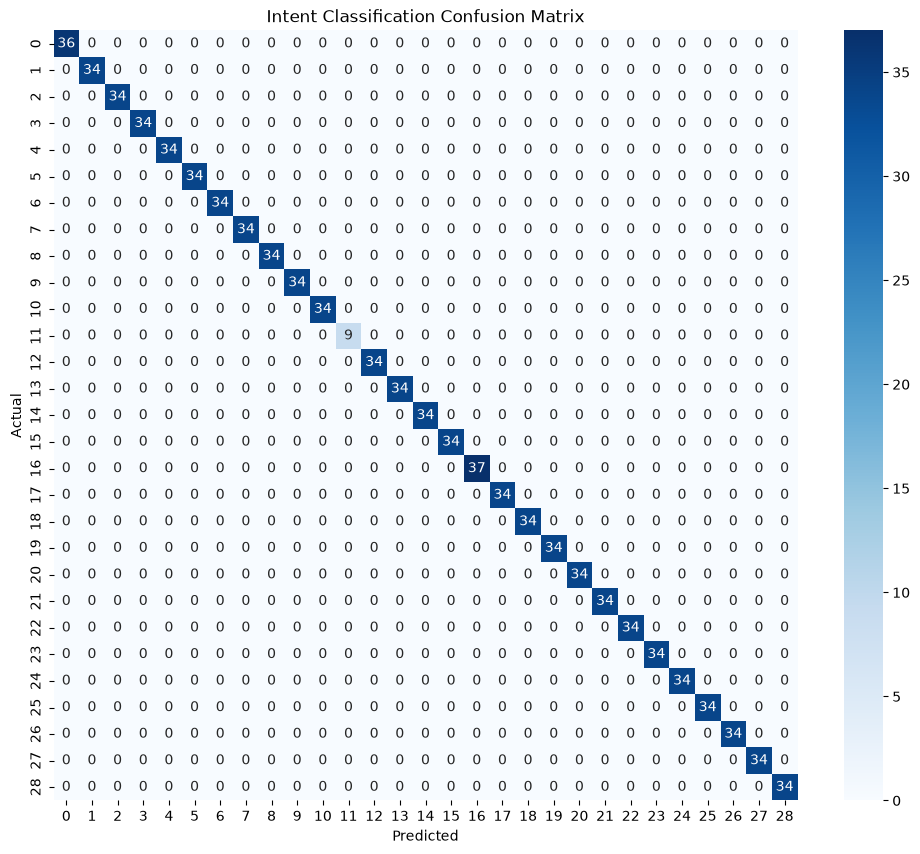

In [159]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Intent Classification Confusion Matrix")
plt.show()

The MLP classifier achieved 100% accuracy on the held-out test set, showing that the intents in the dataset are highly separable. Additional testing with custom user queries confirmed that the model can correctly classify unseen commands.

## 7. Intent-Based Action Execution

This section defines the assistant's response logic by mapping detected user intents to specific actions, such as opening websites, playing music, providing information, setting reminders, or performing calculations. The function processes the predicted intent and user input, executes the corresponding task, and returns an appropriate response.

In [160]:
MEMORY_FILE = r"C:\Users\sarat\Downloads\alexa_project\memory.json"

In [161]:
def load_memory():
    with open("memory.json", "r") as file:
        return json.load(file)

In [162]:
memory = load_memory()
def perform_action(intent,prompt=""):
    if intent=="play_music":
        webbrowser.open("https://www.youtube.com/results?search_query=music")
        return "Playing music on youtube"
    elif intent=="open_website":
        prompt_lower=prompt.lower()
        cleaned=re.sub(r'[a-zA-Z0-9\s]','',prompt_lower)
        if "youtube" in cleaned or "you tube":
            webbrowser.open("https://www.youtube.com/")
            return "Opening Youtube"
        elif "google" in prompt_lower:
            webbrowser.open("https://www.google.com/")
            return "Opening Google"
        elif "github" in prompt_lower:
            webbrowser.open("https://github.com/")
            return "Opening Github"
        else:
            return "Which website would you like me to open?"
    elif intent=="jokes_fun":
        jokes=[
            "Why did the computer get cold? Because it forgot to close the Window!",
            "Why do programmers prefer dark mode? Because light attracts bugs.",
            "I told my AI assistant a joke. It said, processing humor module."
        ]
        return random.choice(jokes)
    elif intent=="news":
        webbrowser.open("https://news.google.com/")
        return "Here's today top headlines."
    elif intent=="movies":
        webbrowser.open("https://www.imdb.com/chart/top/")
        return "Here's todays top movies."
    elif intent=="set_timer":
        minutes=re.findall(r'\d+',prompt)
        minutes=int(minutes[0]) if minutes else 1
        return f"Timer set for {minutes} minutes (simulation)."
    elif intent=="alarm":
        time_match=re.search(r'(\d{1,2}(?::(\d{2}))?\s*(am|pm)?',prompt.lower())
        if time_match:
            hour=int(time_match.group(1))
            minute=int(time_match.group(2) if time_match.group(2) else 0)
            period=time_match.group(3) if time_match.group(3) else "am"
            return f"Alarm set for {hour}:{str(minute).zfill(2)} {period.upper()} simulation"
        return "Alarm set.(simulation)"
    elif intent=="reminder":
        return "Reminder saved.(simulation)"
    elif intent=="date_time":
        now=datetime.datetime.now()
        return f"It's {now.strftime('%I:%M: %p')} on {now.strftime('%B %d, %Y')}"
    elif intent=="calendar":
        return "You have no events today.(simulation)"
    elif intent=="weather":
        prompt_lower=prompt.lower()
        match=re.search(r"(in|of)\s+([a-zA-Z\s]+)",prompt_lower)
        if match:
            city=match.group(2).strip()
            webbrowser.open(f"https://www.google.com/search?q=weather+in+{city.replace(' ','+')}")
            return f"Showing current weather in {city.title()}"
        else:
            webbrowser.open(f"https://www.google.com/search?q=weather+today")
            return "Here's the latest weather forecast."
    elif intent=="general_qa":
        prompt_lower=prompt.lower()
        if any(word in prompt_lower for word in ["temperature","weather","forecast"]):
            match=re.search(r"(in|of)\s+([a-zA-Z\s]+)",prompt_lower)
            if match:
                city=match.group(2).strip()
                webbrowser.open(f"https://www.google.com/search?q=weather+in+{city.replace(' ','+')}")
                return f"Showing current weather in {city.title()}"
        query=prompt.replace(" ","+")
        webbrowser.open(f"https://www.google.com/search?q={query}")
        return "Here's what I found  on the web."
    elif intent=="facts":
        facts=[
            "Honey never spoils.",
            "Octopuses have three hearts.",
            "Tomato is a fruit."
        ]
        return random.choice(facts)
    elif intent=="traffic":
        webbrowser.open(f"https://www.google.com/maps/dir/Home/Office")
        return "Checking traffic on a usual rute."
    elif intent=="directions":
        webbrowser.open(f"https://www.google.com/maps/search/{location}")
        return f"Showing directions to {location}."
    elif intent=="shopping_list":
        item=prompt.lower().replace("to my shopping list","").strip()
        memory["shopping_list"].append(item)
        save_memory(memory)
        return f"Added {item} to your shopping list."
    elif intent=="smart_home":
        return "Command executed.(simulation)"
    elif intent=="personality":
        responses=[
            "I'm doing great!Ready to help you.",
            "I'm your AI assistant!",
            "I waqs created to make your life easier."
        ]
        return random.choice(responses)
    elif intent=="calculator":
        nums=list(map(int,re.findall(r'\d+',prompt)))
        if "plus" in prompt and len(nums)==2:
            return f"The answer is {nums[0]+nums[1]}"
        elif "minus" in prompt and len(nums)==2:
            return f"The answer is {nums[0]-nums[1]}"
        elif "times" in prompt and len(nums)==2:
            return f"The answer is {nums[0]*nums[1]}"
        elif "divide" in prompt and len(nums)==2:
            return f"The answer is {nums[0]/nums[1]}"
    elif intent=="memory":
        memory = load_memory()
        response = f"Your name is {memory['name']}.\n"
        response += f"Your favorite music is {memory['favorite_music']}.\n"
        response += "Your shopping list contains:\n"
        for item in memory["shopping_list"]:
            response += f"- {item}\n"
        return response
    else:
        return "Sorry,I didn't understand the command."
        

In [163]:
user_text="Play song for me."

In [164]:
intent=predict_intent(user_text)
intent

Detected Intent: play_music


np.str_('play_music')

In [165]:
perform_action(intent,user_text)

'Playing music on youtube'

In [36]:
user_text2="Who is the prime minister of Serbia"

In [37]:
intent2=predict_intent(user_text2)
intent2

Detected Intent: general_qa


np.str_('general_qa')

In [38]:
perform_action(intent2,user_text2)

"Here's what I found  on the web."

In [166]:
user_text = "What do you remember about me?"

In [167]:
intent = predict_intent(user_text)

Detected Intent: memory


In [168]:
response = perform_action(intent, user_text)
print(response)

Your name is Sara.
Your favorite music is Metal.
Your shopping list contains:
- milk
- bread



## 8. Persistent Memory

The assistant stores user preferences, including the user's name, favorite music genre, and shopping list, in a JSON file. This allows information to persist across multiple sessions, providing a more personalized user experience.

In [169]:
def save_memory(memory):
    with open("memory.json", "w") as file:
        json.dump(memory, file, indent=4)

In [170]:
memory = load_memory()

In [171]:
def remember_name(name):
    memory["name"] = name
    save_memory(memory)

In [172]:
remember_name("Sara")

In [173]:
memory["favorite_music"]="Metal"
save_memory(memory)

## 9. Voice Output and Assistant Pipeline

This section initializes the text-to-speech engine using pyttsx3 and configures the voice, speech rate, and volume settings. The run_assistant() function connects all components of the system by recording audio, converting speech to text, predicting the user's intent, performing the corresponding action, and generating a spoken response.

In [174]:
engine=pyttsx3.init("sapi5")

In [175]:
voices=engine.getProperty("voices")

In [176]:
engine.setProperty("voice",voices[1].id)
engine.setProperty("rate",165)
engine.setProperty("volumn",1.0)

In [177]:
def speak(text):
    print("Alexa:",text)
    engine.say(text)
    engine.runAndWait()

In [178]:
def run_assistant():
    if memory["name"] != "":
        speak(f"Welcome back {memory['name']}")
    record_audio("input.wav")
    text=speech_to_text("input.wav")
    intent=predict_intent(text)
    response=perform_action(intent,text)
    speak(response)
    
    

In [183]:
run_assistant()

Alexa: Welcome back Sara
🎤 Listening...
✅ Audio recorded
 What do you remember about me?
Detected Intent: memory
Alexa: Your name is Sara.
Your favorite music is Metal.
Your shopping list contains:
- milk
- bread

